In [22]:
import pandas as pd

df=pd.read_csv("train.csv")
x_test=pd.read_csv("test.csv")
test=pd.read_csv("sample_submission.csv")
x_train=df.drop("SalePrice",axis=1)
y_train=df["SalePrice"]

In [23]:
combined= pd.concat([x_train,x_test])
combined=pd.get_dummies(combined)
combined = combined.fillna(0)
x_train=combined[:len(x_train)]
x_test=combined[len(x_train):]


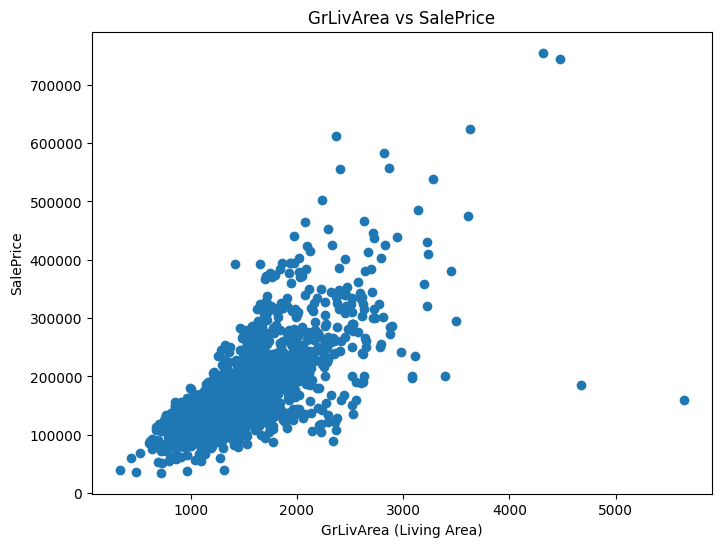

In [24]:

import matplotlib.pyplot as plt
# Scatter plot: GrLivArea vs SalePrice
plt.figure(figsize=(8,6))
plt.scatter(df["GrLivArea"], df["SalePrice"])

# Labels and title
plt.xlabel("GrLivArea (Living Area)")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")

# Show plot
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)


predictions = model.predict(x_test)

In [26]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file created 🚀")

Submission file created 🚀


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split training data
X_tr, X_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Train model
model.fit(X_tr, y_tr)

# Predict on validation set
y_pred = model.predict(X_val)

# Metrics
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 21196.441517504023
RMSE: 65376.75413725747
R2: 0.4427720717381557
